# **Temporal difference0 (TD0)**

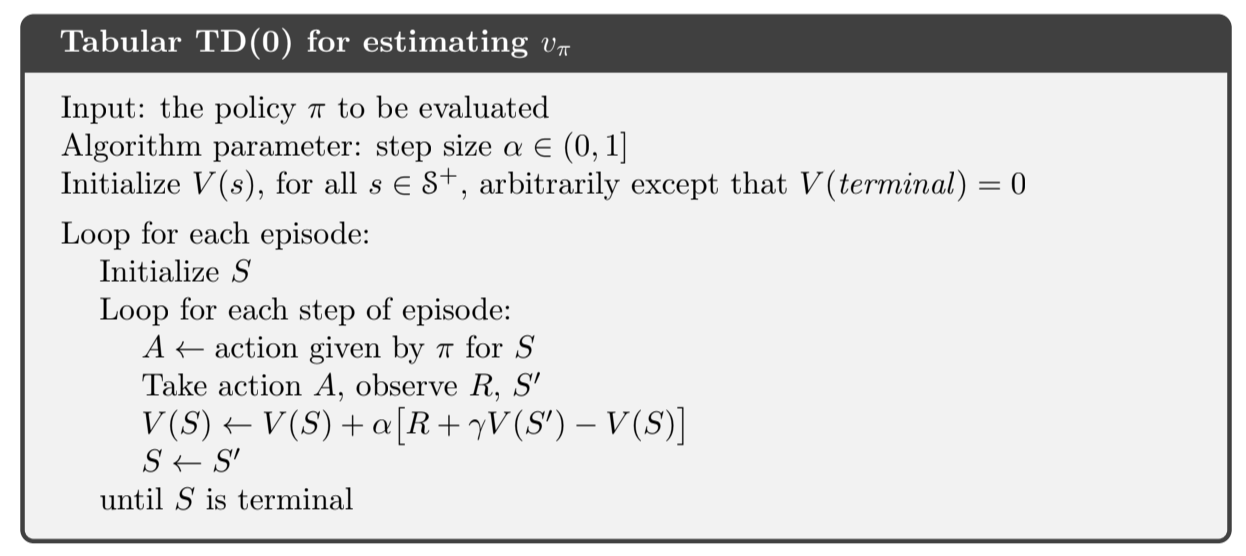

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import random

# **Functions**

In [45]:
def Environment(AllStates, State, Action, Goal):

  Row = State[0]
  Col = State[1]

  RowV = Action[0]
  ColV = Action[1]

  NewState = np.array([Row + RowV, Col + ColV])

  if np.any(np.all(AllStates == NewState, axis=1)):
    if np.all(Goal == NewState):
      Reward = 10
    else:
      Reward = -1
  else:
    Reward = -10
    NewState = np.array([Row, Col])


  if np.all(Goal == np.array([Row, Col])):
    Reward = 0
    NewState = np.array([Row, Col])


  return NewState, Reward


#################################################################################
def PolicyImprovement(plane, AllStates, AllActions, PlaneSized, InitialStates, Vs, Goal):

  # Policy ########################################################
  VectorForBestPolicy = np.zeros(AllStates.shape[0])

  for i in range(AllStates.shape[0]):

    ActionRewardDown = Environment(AllStates, AllStates[i], AllActions[0], Goal)
    IndexDown = np.where(np.all(AllStates == ActionRewardDown[0], axis=1))

    ActionRewardUp = Environment(AllStates, AllStates[i], AllActions[1], Goal)
    IndexUp = np.where(np.all(AllStates == ActionRewardUp[0], axis=1))

    ActionRewardRight = Environment(AllStates, AllStates[i], AllActions[2], Goal)
    IndexRight = np.where(np.all(AllStates == ActionRewardRight[0], axis=1))

    ActionRewardLeft = Environment(AllStates, AllStates[i], AllActions[3], Goal)
    IndexLeft = np.where(np.all(AllStates == ActionRewardLeft[0], axis=1))

    VectorForBestPolicyMain = [ActionRewardDown[1] + Gamma * Vs[IndexDown][0],
                                ActionRewardUp[1] + Gamma * Vs[IndexUp][0],
                                ActionRewardRight[1] + Gamma * Vs[IndexRight][0],
                                ActionRewardLeft[1] + Gamma * Vs[IndexLeft][0]
                              ]


    max_val = np.max(VectorForBestPolicyMain)
    index_max = np.where(np.array(VectorForBestPolicyMain) == max_val)[0]

    VectorForBestPolicy[i] = random.choice(index_max)
    VectorForBestPolicy = np.rint(VectorForBestPolicy).astype(int)


  return VectorForBestPolicy

# **Create the environment with code (without gym library)**
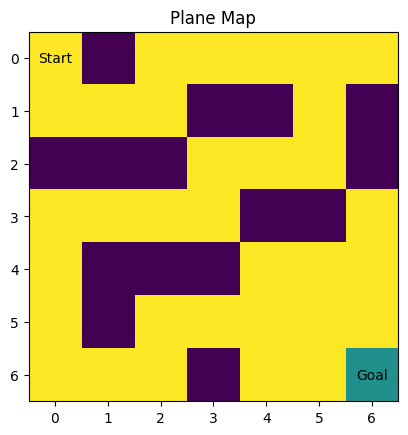

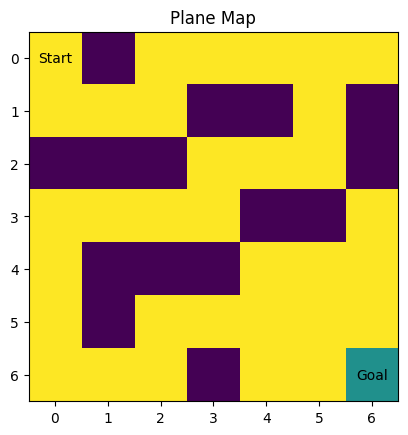

In [46]:
PlaneSized = 7
OneStates = []
Gamma = 0.99
InitialStates = np.array([0, 0])

Plane = np.ones((PlaneSized, PlaneSized)) # 1 means free and 0 means barrier
barriers = [
    (0, 1),
    (1, 3), (1, 4), (1, 6),
    (2, 0), (2, 1), (2, 2), (2, 6),
    (3, 4), (3, 5),
    (4, 1), (4, 2), (4, 3),
    (5, 1),
    (6, 3)
]
Goal = np.array([6, 6])
for r, c in barriers:
    Plane[r, c] = 0

for i in range(PlaneSized):
  for j in range(PlaneSized):
    if Plane[i, j] == 1:
      OneStates.append([i, j])


AllActions = np.array([[1, 0], [-1, 0], [0, 1], [0, -1]]) # [1, 0]: Down_0, [-1, 0]: Up_1, [0, 1]: Right_2, [0, -1]: Left_3
AllStates = np.array(OneStates)

Plane[Goal[0], Goal[1]] = 0.5

plt.imshow(Plane)
plt.text(Goal[1], Goal[0], 'Goal', fontsize=10, color='Black', ha='center', va='center')
plt.text(0, 0, 'Start', fontsize=10, color='Black', ha='center', va='center')
plt.title("Plane Map")
plt.xticks(range(PlaneSized))
plt.yticks(range(PlaneSized))
plt.show()

# **Temporal difference0 (TD0)**

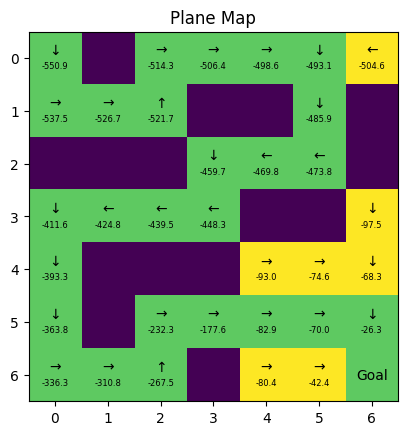

In [47]:
V = np.zeros(AllStates.shape[0])

episod = 200
alpha = 0.1


for i in range(episod):

  V_old = V.copy()

  CurrentState = AllStates[np.random.randint(AllStates.shape[0])]

  while True:

    Action = AllActions[np.random.randint(AllActions.shape[0])]
    NewState, Reward = Environment(AllStates, CurrentState, Action, Goal)

    index_CurrentState = np.where(np.all(AllStates == CurrentState , axis=1))[0][0]
    index_NextState = np.where(np.all(AllStates == NewState , axis=1))[0][0]


    # Temporal difference0 (TD0) ###################################################
    V[index_CurrentState] = V[index_CurrentState] + alpha * (Reward + Gamma * V[index_NextState] - V[index_CurrentState])

    CurrentState = NewState

    if(np.array_equal(CurrentState, Goal)):
      break

  if np.linalg.norm(V_old - V) < 1e-4:
    break



Policy = PolicyImprovement(Plane, AllStates, AllActions, PlaneSized, InitialStates, V, Goal)
# print(Policy)



# Down_0, Up_1, Right_2, Left_3
directionPolicy = np.empty(Policy.shape[0], dtype=object)
for i in range(Policy.shape[0]):
  if Policy[i] == 0:
    directionPolicy[i] = '↓'
  elif Policy[i] == 1:
    directionPolicy[i] = '↑'
  elif Policy[i] == 2:
    directionPolicy[i] = '→'
  else:
    directionPolicy[i] = '←'


Plane2 = Plane.copy()
plt.imshow(Plane2)


Plane2[InitialStates[0], InitialStates[1]]= 0.75
plt.imshow(Plane2)


for i in range(Policy.size-1):
  MovingInPlaneIndex = np.where(np.all(AllStates == InitialStates , axis=1))
  InitialStatesNext = InitialStates + AllActions[Policy[MovingInPlaneIndex]]
  InitialStates = InitialStatesNext
  Plane2[InitialStatesNext[0][0], InitialStatesNext[0][1]]= 0.75
  plt.imshow(Plane2)

  if np.all(Goal == InitialStatesNext , axis=1):
    break



for i in range(Policy.size-1):
  plt.text(AllStates[i][1], AllStates[i][0] + 0.15, round(V[i], 1), fontsize=6, color='Black', ha='center', va='center')
  plt.text(AllStates[i][1], AllStates[i][0] - 0.15, directionPolicy[i], fontsize=10, color='Black', ha='center', va='center')


plt.text(Goal[1], Goal[0], 'Goal', fontsize=10, color='Black', ha='center', va='center')

plt.title("Plane Map")
plt.xticks(range(PlaneSized))
plt.yticks(range(PlaneSized))
plt.show()